## Loading and preparing the dataset

In [ ]:
import os
import re
import random
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

!kaggle datasets download -d adityajn105/flickr8k

cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
Dataset URL: https://www.kaggle.com/datasets/adityajn105/flickr8k
License(s): CC0-1.0
100% 1.04G/1.04G [00:11<00:00, 98.7MB/s]



In [ ]:
!unzip -q flickr8k.zip

In [ ]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [ ]:
MAX_LEN = 30  # Captions can be slightly longer but used this to avoid too much compute
BATCH_SIZE = 32
PAD, SOS, EOS, UNK = "<pad>", "<sos>", "<eos>", "<unk>"

In [ ]:
caption_path = '/content/captions.txt'
img_dir = '/content/Images/'

data = []
with open(caption_path, 'r', encoding='utf-8') as f:
    lines = f.readlines()

# Skip header if it exists
start_idx = 1 if lines[0].strip().lower().startswith('image,caption') else 0

for line in lines[start_idx:]:
    # Split ONLY on the first comma to prevent breaking captions that contain commas
    parts = line.strip().split(',', 1)
    if len(parts) == 2:
        img_name, caption = parts
        data.append({
            'image_path': os.path.join(img_dir, img_name),
            'caption': caption
        })

df = pd.DataFrame(data)
print(f"Loaded {len(df)} image-caption pairs.")

Loaded 40455 image-caption pairs.


In [ ]:
def tokenize(sentence):
    sentence = str(sentence).lower().strip()
    sentence = re.sub(r"([.!?,])", r" \1 ", sentence)
    sentence = re.sub(r"[^a-z0-9.!?,' ]+", " ", sentence)
    sentence = re.sub(r"\s+", " ", sentence).strip()
    return sentence.split(" ") if sentence else []

df['tokens'] = df['caption'].apply(tokenize)

In [ ]:
unique_images = df['image_path'].unique()
random.shuffle(unique_images)

train_imgs = unique_images[:7000]
val_imgs = unique_images[7000:7500]     # 500 images for validation
test_imgs = unique_images[7500:]        # Remaining images for testing

train_df = df[df['image_path'].isin(train_imgs)]
val_df = df[df['image_path'].isin(val_imgs)]
test_df = df[df['image_path'].isin(test_imgs)]

print(f"Train: {len(train_imgs)} images ({len(train_df)} captions)")
print(f"Val:   {len(val_imgs)} images ({len(val_df)} captions)")
print(f"Test:  {len(test_imgs)} images ({len(test_df)} captions)")

Train: 7000 images (35000 captions)
Val:   500 images (2500 captions)
Test:  591 images (2955 captions)


In [ ]:
class Vocab:
    def __init__(self, token_lists, min_freq=2):
        from collections import Counter
        counter = Counter(tok for tokens in token_lists for tok in tokens)
        self.itos = [PAD, SOS, EOS, UNK] + [w for w, c in counter.items() if c >= min_freq]
        self.stoi = {w: i for i, w in enumerate(self.itos)}

    def encode(self, tokens, add_sos_eos=True):
        ids = [self.stoi.get(t, self.stoi[UNK]) for t in tokens]
        if add_sos_eos:
            ids = [self.stoi[SOS]] + ids + [self.stoi[EOS]]
        return ids

    def __len__(self):
        return len(self.itos)

In [ ]:
vocab = Vocab(train_df['tokens'].tolist(), min_freq=2)
print(f"Vocabulary size: {len(vocab)}")

Vocabulary size: 4843


In [ ]:
def load_and_preprocess_image(img_path):
    img_raw = tf.io.read_file(img_path)
    # decode_image handles JPEG/PNG automatically
    img = tf.image.decode_image(img_raw, channels=3, expand_animations=False)
    img = tf.image.resize(img, (224, 224))
    # ResNet50 specific preprocessing (converts to BGR and zero-centers based on ImageNet stats)
    img = tf.keras.applications.resnet50.preprocess_input(img)
    return img

In [ ]:
def make_dataset(image_paths, captions, vocab, batch_size=32, shuffle=False):
    cap_ids = [vocab.encode(c, add_sos_eos=True) for c in captions]
    cap_ids = tf.keras.preprocessing.sequence.pad_sequences(cap_ids, padding="post", maxlen=MAX_LEN)

    ds = tf.data.Dataset.from_tensor_slices((image_paths, cap_ids))
    if shuffle:
        ds = ds.shuffle(len(image_paths), seed=SEED)

    # Map image loading and preprocessing
    ds = ds.map(lambda path, cap: (load_and_preprocess_image(path), cap), num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds

In [ ]:
train_ds = make_dataset(train_df['image_path'].tolist(), train_df['tokens'].tolist(), vocab, BATCH_SIZE, shuffle=True)
val_ds = make_dataset(val_df['image_path'].tolist(), val_df['tokens'].tolist(), vocab, BATCH_SIZE)
test_ds = make_dataset(test_df['image_path'].tolist(), test_df['tokens'].tolist(), vocab, BATCH_SIZE)

## Preparing the model architecture

In [ ]:
def positional_encoding_matrix(dims, max_len):
    positions = np.arange(max_len)[:, np.newaxis]
    i = np.arange(dims // 2)[np.newaxis, :]

    angle_rates = 1 / np.power(10000, (2 * i) / dims)
    angles = positions * angle_rates

    pos_encoding = np.zeros((max_len, dims))
    pos_encoding[:, 0::2] = np.sin(angles)
    pos_encoding[:, 1::2] = np.cos(angles)

    return pos_encoding

In [ ]:
class self_attention(tf.keras.Model):
  def __init__(self, d_model, num_heads):
    super().__init__()
    self.d_model = d_model
    self.d_k = d_model // num_heads
    self.wq = tf.keras.layers.Dense(self.d_k)
    self.wk = tf.keras.layers.Dense(self.d_k)
    self.wv = tf.keras.layers.Dense(self.d_k) # 128 in this case

  def call(self, src_embeddings):
    Q = self.wq(src_embeddings)
    K = self.wk(src_embeddings)
    V = self.wv(src_embeddings)
    q_k_dot_product = tf.matmul(Q, K, transpose_b=True)
    scaled_q_k_dot_product = q_k_dot_product / np.sqrt(self.d_k)
    attention_weights = tf.nn.softmax(scaled_q_k_dot_product, axis=-1)
    contextualized_vector = tf.matmul(attention_weights, V)
    return contextualized_vector

In [ ]:
class MultiHeadAttention(tf.keras.layers.Layer):
  def __init__(self, d_model, num_heads):
      super().__init__()
      self.heads = [self_attention(d_model, num_heads) for _ in range(num_heads)]
      self.wo = tf.keras.layers.Dense(d_model)

  def call(self, src_embeddings):
      head_outputs = [head(src_embeddings) for head in self.heads]   # each: [batch, seq_len, d_k]
      concat = tf.concat(head_outputs, axis=-1)                       # [batch, seq_len, d_model]
      return self.wo(concat)

In [ ]:
class ffn(tf.keras.layers.Layer):
  def __init__(self, d_model, d_ff):
    super().__init__()
    self.fc1 = tf.keras.layers.Dense(d_ff, activation='relu')
    self.fc2 = tf.keras.layers.Dense(d_model)

  def call(self, x):
    x = self.fc1(x)
    x = self.fc2(x)
    return x

In [ ]:
class masked_self_attention(tf.keras.layers.Layer):
  def __init__(self, d_model, num_heads):
    super().__init__()
    self.d_model = d_model
    self.d_k = d_model // num_heads
    self.wq = tf.keras.layers.Dense(self.d_k)
    self.wk = tf.keras.layers.Dense(self.d_k)
    self.wv = tf.keras.layers.Dense(self.d_k) # 128 in this case

  def causal_mask(self,seq_len):
    # Upper triangle (excluding diagonal) = 1 -> gets masked; diagonal and below = 0 -> stays visible
    mask = np.triu(np.ones((seq_len, seq_len)), k=1)          # [seq_len, seq_len]
    return tf.cast(np.where(mask == 1, -np.inf, 0.0), tf.float32)

  def call(self, src_embeddings):
    Q = self.wq(src_embeddings)
    K = self.wk(src_embeddings)
    V = self.wv(src_embeddings)
    q_k_dot_product = tf.matmul(Q, K, transpose_b=True)
    scaled_q_k_dot_product = q_k_dot_product / np.sqrt(self.d_k)
    masked_scaled_q_k_dot_product = scaled_q_k_dot_product + self.causal_mask(scaled_q_k_dot_product.shape[-1])
    attention_weights = tf.nn.softmax(masked_scaled_q_k_dot_product, axis=-1)
    contextualized_vector = tf.matmul(attention_weights, V)
    return contextualized_vector

In [ ]:
class masked_multi_head_attention(tf.keras.layers.Layer):
  def __init__(self, d_model, num_heads):
      super().__init__()
      self.heads = [masked_self_attention(d_model, num_heads) for _ in range(num_heads)]
      self.wo = tf.keras.layers.Dense(d_model)

  def call(self, src_embeddings):
      head_outputs = [head(src_embeddings) for head in self.heads]
      concat = tf.concat(head_outputs, axis=-1)                       # [batch, seq_len, d_model]
      return self.wo(concat)

In [ ]:
class cross_attention(tf.keras.layers.Layer):
  def __init__(self, d_model, num_heads):
    super().__init__()
    self.d_model = d_model
    self.d_k = d_model // num_heads
    self.wq = tf.keras.layers.Dense(self.d_k)
    self.wk = tf.keras.layers.Dense(self.d_k)
    self.wv = tf.keras.layers.Dense(self.d_k)

  def call(self, src_embeddings, tgt_embeddings):
    Q = self.wq(tgt_embeddings)
    K = self.wk(src_embeddings)
    V = self.wv(src_embeddings)
    q_k_dot_product = tf.matmul(Q, K, transpose_b=True)
    scaled_q_k_dot_product = q_k_dot_product / np.sqrt(self.d_k)
    attention_weights = tf.nn.softmax(scaled_q_k_dot_product, axis=-1)
    contextualized_vector = tf.matmul(attention_weights, V)
    return contextualized_vector

In [ ]:
class multi_head_cross_attention(tf.keras.layers.Layer):
  def __init__(self, d_model, num_heads):
      super().__init__()
      self.heads = [cross_attention(d_model, num_heads) for _ in range(num_heads)]
      self.wo = tf.keras.layers.Dense(d_model)

  def call(self, src_embeddings, tgt_embeddings):
      head_outputs = [head(src_embeddings, tgt_embeddings) for head in self.heads]
      concat = tf.concat(head_outputs, axis=-1)                       # [batch, seq_len, d_model]
      return self.wo(concat)

In [ ]:

class Decoder(tf.keras.layers.Layer):
  def __init__(self, d_model, num_heads, d_ff):
    super().__init__()
    self.d_model = d_model
    self.num_heads = num_heads
    self.d_ff = d_ff
    self.masked_self_attention = masked_multi_head_attention(d_model, num_heads)
    self.cross_attention = multi_head_cross_attention(d_model, num_heads)
    self.ffn = ffn(d_model, d_ff)
    self.layernorm1 = tf.keras.layers.LayerNormalization(epsilon=1e-6)
    self.layernorm2 = tf.keras.layers.LayerNormalization(epsilon=1e-6)
    self.layernorm3 = tf.keras.layers.LayerNormalization(epsilon=1e-6)

  def call(self, target_embeddings, encoder_output):
    masked_contextual_input = self.masked_self_attention(target_embeddings)
    output = self.layernorm1(target_embeddings + masked_contextual_input)
    cross_attention_output = self.cross_attention(encoder_output, output)
    output = self.layernorm2(output + cross_attention_output)
    ffn_output = self.ffn(output)
    decoder_output = self.layernorm3(output + ffn_output)
    return decoder_output

In [ ]:
class ImageEncoder(tf.keras.layers.Layer):
    def __init__(self, d_model=512):
        super().__init__()
        # ResNet50 without the top classification layer
        self.resnet = tf.keras.applications.ResNet50(include_top=False, weights='imagenet', input_shape=(224, 224, 3))
        self.resnet.trainable = False

        self.ffn = tf.keras.Sequential([
            tf.keras.layers.Dense(128, activation='relu'),
            tf.keras.layers.Dense(d_model, activation='linear')
        ])

    def call(self, images):
        # images shape: (batch, 224, 224, 3)
        features = self.resnet(images)  # shape: (batch, 7, 7, 2048)
        batch_size = tf.shape(features)[0]

        # Flatten spatial dimensions to 49 "visual words"
        features = tf.reshape(features, (batch_size, 49, 2048))

        # Project to d_model (512)
        return self.ffn(features)  # shape: (batch, 49, 512)

In [ ]:
class ImageCaptioner(tf.keras.Model):
    def __init__(self, d_model, num_heads, d_ff, target_vocab_size):
        super().__init__()
        self.d_model = d_model
        self.num_heads = num_heads
        self.d_ff = d_ff
        self.target_vocab_size = target_vocab_size # Store for get_config

        self.image_encoder = ImageEncoder(d_model)

        self.tgt_embedding = tf.keras.layers.Embedding(target_vocab_size, d_model, mask_zero=True)
        self.tgt_pos_encoding = tf.constant(positional_encoding_matrix(d_model, MAX_LEN), dtype=tf.float32)

        # 3 Decoder Layers as in your original architecture
        self.decoder1 = Decoder(d_model, num_heads, d_ff)
        self.decoder2 = Decoder(d_model, num_heads, d_ff)
        self.decoder3 = Decoder(d_model, num_heads, d_ff)

        self.linear = tf.keras.layers.Dense(target_vocab_size)

    def call(self, images, tgt):
        encoder_output = self.image_encoder(images) # (batch, 49, 512)

        # 2. Embed Target Text
        tgt_seq_len = tf.shape(tgt)[1]
        tgt_embeddings = self.tgt_embedding(tgt)
        tgt_embeddings = tgt_embeddings + self.tgt_pos_encoding[tf.newaxis, :tgt_seq_len, :]

        # 3. Pass through Decoders
        # Note: All decoder layers attend to the SAME image features
        dec_out1 = self.decoder1(tgt_embeddings, encoder_output)
        dec_out2 = self.decoder2(dec_out1, encoder_output)
        dec_out3 = self.decoder3(dec_out2, encoder_output)

        return self.linear(dec_out3)

    def get_config(self):
        config = super().get_config()
        config.update({
            "d_model": self.d_model,
            "num_heads": self.num_heads,
            "d_ff": self.d_ff,
            "target_vocab_size": self.target_vocab_size,
        })
        return config

In [ ]:
def patch_get_config(cls, arg_names):
    """Dynamically adds the get_config method to a Keras class."""
    def get_config(self):
        # Get the default Keras configuration
        config = super(cls, self).get_config()
        # Add the custom arguments your __init__ requires
        for arg in arg_names:
            if hasattr(self, arg):
                config[arg] = getattr(self, arg)
        return config
    # Attach the method to the class
    cls.get_config = get_config

# 1. Patch the Main Model
patch_get_config(ImageCaptioner, ['d_model', 'num_heads', 'd_ff', 'target_vocab_size'])

# 2. Patch the Image Encoder and Text Decoder
patch_get_config(ImageEncoder, ['d_model'])
patch_get_config(Decoder, ['d_model', 'num_heads', 'd_ff'])

# 3. Patch all your custom Attention & FFN layers from the original notebook
patch_get_config(ffn, ['d_model', 'd_ff'])
patch_get_config(self_attention, ['d_model', 'num_heads'])
patch_get_config(MultiHeadAttention, ['d_model', 'num_heads'])
patch_get_config(masked_self_attention, ['d_model', 'num_heads'])
patch_get_config(masked_multi_head_attention, ['d_model', 'num_heads'])
patch_get_config(cross_attention, ['d_model', 'num_heads'])
patch_get_config(multi_head_cross_attention, ['d_model', 'num_heads'])

print("✅ All classes successfully patched! You can now run model.save().")

✅ All classes successfully patched! You can now run model.save().


In [ ]:
loss_object = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True, reduction="none")

def masked_loss(real, pred):
    mask = tf.cast(tf.not_equal(real, 0), dtype=tf.float32)
    loss_ = loss_object(real, pred) * mask
    return tf.reduce_sum(loss_) / (tf.reduce_sum(mask) + 1e-8)

In [ ]:
class WarmupSchedule(tf.keras.optimizers.schedules.LearningRateSchedule):
    def __init__(self, d_model, warmup_steps=4000):
        super().__init__()
        self.d_model = tf.cast(d_model, tf.float32)
        self.warmup_steps = warmup_steps
    def __call__(self, step):
        step = tf.cast(step, tf.float32)
        arg1 = tf.math.rsqrt(step)
        arg2 = step * (self.warmup_steps ** -1.5)
        return tf.math.rsqrt(self.d_model) * tf.math.minimum(arg1, arg2)

In [ ]:
D_MODEL, NUM_HEADS, D_FF, EPOCHS = 512, 4, 2048, 15
model = ImageCaptioner(D_MODEL, NUM_HEADS, D_FF, len(vocab))

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [ ]:
optimizer = tf.keras.optimizers.Adam(learning_rate=WarmupSchedule(D_MODEL), beta_1=0.9, beta_2=0.98, epsilon=1e-9)

In [ ]:
@tf.function
def train_step(model, images, tgt, optimizer):
    tgt_input = tgt[:, :-1]    # what the decoder sees (shifted right)
    tgt_real = tgt[:, 1:]      # what the decoder should predict (shifted left)

    with tf.GradientTape() as tape:
        # Pass images through ResNet Encoder, and tgt_input through Decoder
        predictions = model(images, tgt_input)
        loss = masked_loss(tgt_real, predictions)

    # Calculate gradients and clip them to prevent exploding gradients
    gradients = tape.gradient(loss, model.trainable_variables)
    grad_norm = tf.linalg.global_norm(gradients)
    gradients, _ = tf.clip_by_global_norm(gradients, 1.0)

    # Apply updates
    optimizer.apply_gradients(zip(gradients, model.trainable_variables))

    return loss, grad_norm

In [ ]:
def train_one_epoch(model, dataset, optimizer):
    total_loss, total_grad_norm, n_batches = 0.0, 0.0, 0

    for images, tgt in dataset:
        loss, grad_norm = train_step(model, images, tgt, optimizer)
        total_loss += loss.numpy()
        total_grad_norm += grad_norm.numpy()
        n_batches += 1

    return total_loss / n_batches, total_grad_norm / n_batches

## training loop

In [ ]:
history = []
for epoch in range(EPOCHS):
    loss, grad_norm = train_one_epoch(model, train_ds, optimizer)
    history.append({"epoch": epoch, "loss": loss, "grad_norm": grad_norm})
    print(f"Epoch {epoch+1}/{EPOCHS} | Loss: {loss:.4f} | Grad Norm: {grad_norm:.4f}")

Epoch 1/15 | Loss: 4.6866 | Grad Norm: 5.1413
Epoch 2/15 | Loss: 3.2624 | Grad Norm: 3.1333
Epoch 3/15 | Loss: 2.9659 | Grad Norm: 2.4629
Epoch 4/15 | Loss: 2.8902 | Grad Norm: 2.7911
Epoch 5/15 | Loss: 2.7662 | Grad Norm: 3.2155
Epoch 6/15 | Loss: 2.6141 | Grad Norm: 3.3198
Epoch 7/15 | Loss: 2.4675 | Grad Norm: 3.1379
Epoch 8/15 | Loss: 2.3387 | Grad Norm: 3.1648
Epoch 9/15 | Loss: 2.2381 | Grad Norm: 3.5297
Epoch 10/15 | Loss: 2.1276 | Grad Norm: 3.3181
Epoch 11/15 | Loss: 2.0292 | Grad Norm: 3.2858
Epoch 12/15 | Loss: 1.9391 | Grad Norm: 3.3195
Epoch 13/15 | Loss: 1.8630 | Grad Norm: 3.7113
Epoch 14/15 | Loss: 1.7803 | Grad Norm: 3.3332
Epoch 15/15 | Loss: 1.7059 | Grad Norm: 3.2024


## Inferencing

In [ ]:
def generate_caption(image_path, max_len=20):
    # Load and preprocess single image
    img = load_and_preprocess_image(image_path)
    img = tf.expand_dims(img, 0) # Add batch dimension

    # Encode image once
    encoder_output = model.image_encoder(img) # (1, 49, 512)

    output_ids = [vocab.stoi[SOS]]

    for i in range(max_len):
        tgt_input_tokens = tf.expand_dims(output_ids, 0)
        tgt_seq_len = tf.shape(tgt_input_tokens)[1]
        tgt_embeddings = model.tgt_embedding(tgt_input_tokens)
        tgt_embeddings = tgt_embeddings + model.tgt_pos_encoding[tf.newaxis, :tgt_seq_len, :]

        dec_out1 = model.decoder1(tgt_embeddings, encoder_output)
        dec_out2 = model.decoder2(dec_out1, encoder_output)
        dec_out3 = model.decoder3(dec_out2, encoder_output)

        predictions = model.linear(dec_out3)
        next_token = tf.argmax(predictions[0, -1, :]).numpy()

        if next_token == vocab.stoi[EOS]:
            break
        output_ids.append(int(next_token))

    return " ".join(vocab.itos[i] for i in output_ids[1:])

In [ ]:
from PIL import Image
import textwrap

def visualize_prediction(image_path, caption):
    # Open the image using PIL
    img = Image.open(image_path)

    # Wrap the caption text so it doesn't overflow the image boundaries
    wrapped_caption = "\n".join(textwrap.wrap(caption, width=45))

    # Create figure
    plt.figure(figsize=(8, 10))
    plt.imshow(img)
    plt.axis('off')

    # Display the caption below the image in a neat bounding box
    plt.figtext(0.5, 0.1, f"Generated Caption:\n{wrapped_caption}",
                wrap=True, horizontalalignment='center', fontsize=14, fontweight='bold',
                bbox={'facecolor': '#f0f0f0', 'alpha': 0.8, 'pad': 15, 'edgecolor': 'gray'})

    # Adjust layout to make room for the text at the bottom
    plt.tight_layout(rect=[0, 0.2, 1, 1])
    plt.show()

In [ ]:
test_img_path = test_df.iloc[90]['image_path']
# print("Generated Caption:", generate_caption(test_img_path))

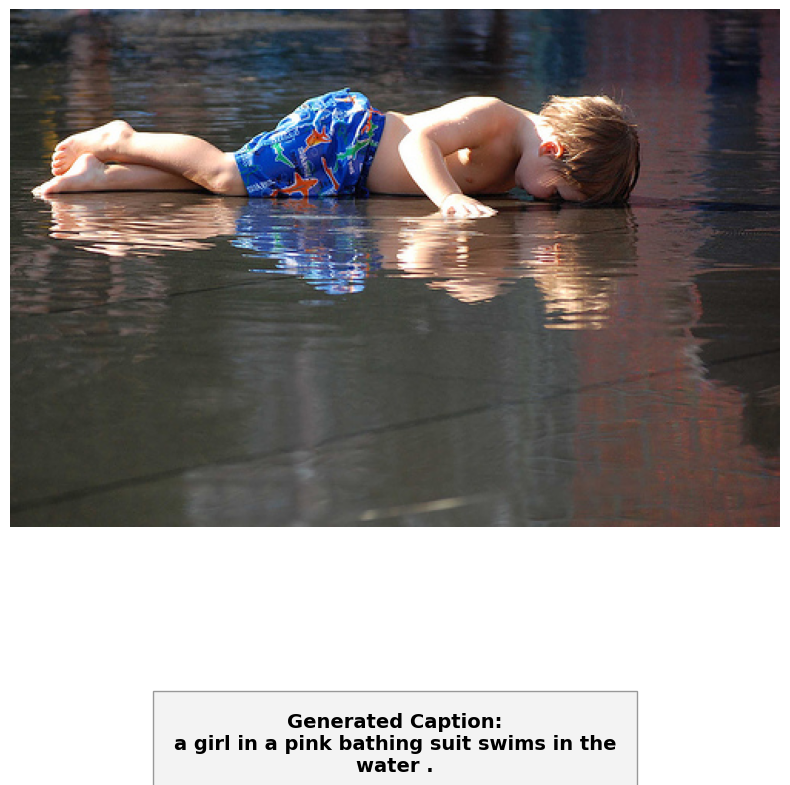

In [ ]:
visualize_prediction(test_img_path, generate_caption(test_img_path))

## Saving the model and vocabulary

In [ ]:
import json
from google.colab import files

# 1. Save the Keras model (Architecture + Weights)
model.save('image_captioner.keras')
print("Model saved to image_captioner.keras")

# 2. Save the Vocabulary
vocab_dict = {
    'itos': vocab.itos,
    'stoi': vocab.stoi
}
with open('vocab.json', 'w') as f:
    json.dump(vocab_dict, f)
print("Vocabulary saved to vocab.json")

Model saved to image_captioner.keras
Vocabulary saved to vocab.json


In [ ]:
files.download('image_captioner.keras')
files.download('vocab.json')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>